# notebook 2 — Extracción de Representaciones y EDA

## Preguntas que guían este notebook

| # | Pregunta |
|---|---|
| 1 | ¿Las features fueron extraídas para **todos** los audios? |
| 2 | ¿Las dos representaciones están alineadas por `file_id`? |
| 3 | ¿Existen features constantes, NaN o valores infinitos? |
| 4 | ¿Qué estructura muestran las features dentro del development pool? |
| 5 | ¿La geometría está dominada por **emoción**, por **actor** o por ambos? |
| 6 | ¿Cuántos componentes PCA son necesarios para retener el 95% de la varianza? |

---

## Representaciones a extraer

| Representación | Modelo | Dims | Estrategia |
|---|---|---|---|
| **eGeMAPSv02** | openSMILE Functionals | 88 | Features acústicas interpretables (F0, loudness, MFCC, jitter…) |
| **wav2vec2** | `facebook/wav2vec2-base` frozen | 768 | Mean pooling sobre `last_hidden_state`; encoder completamente congelado |

---
## 0 · Setup

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import get_config, resolve_path
from src.utils.reproducibility import set_global_seed
from src.utils.logging import get_logger
from src.utils.io import load_metadata, load_splits
from src.config.contracts import PARTITION_DEVELOPMENT

cfg = get_config()
logger = get_logger("notebook2")
set_global_seed(cfg.seed)

METADATA_PATH = resolve_path(cfg.paths.metadata)
SPLITS_PATH = resolve_path(cfg.paths.splits)
FEATURES_DIR = resolve_path(cfg.paths.features_dir)
FIGURES_DIR = resolve_path(cfg.paths.figures_dir)
REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

metadata = load_metadata(METADATA_PATH)
splits = load_splits(SPLITS_PATH)

print(f"Metadata cargada: {metadata.shape[0]} filas × {metadata.shape[1]} columnas")
print(f"Splits cargados: {splits.shape[0]} filas × {splits.shape[1]} columnas")
print(f"Development pool: {(splits['partition'] == PARTITION_DEVELOPMENT).sum()} muestras")

Metadata cargada: 1440 filas × 23 columnas
Splits cargados: 1440 filas × 3 columnas
Development pool: 1200 muestras


---
## 1 · Extracción de eGeMAPSv02

**eGeMAPSv02 Functionals** — 88 features acústicas estadísticas extraídas con openSMILE sobre toda la duración del audio trimmeado.

Las features incluyen estadísticos (media, percentiles, pendiente) de:
- **Prosódicas:** F0 (pitch), loudness, shimmer
- **Calidad vocal:** jitter, HNR, spectral flux
- **Espectrales:** MFCCs (1-4), alpha ratio, Hammarberg index
- **Temporales:** rate of loudness peaks, voiced/unvoiced segments

La extracción usa caché: si `egemaps.parquet` ya existe, lo carga directamente.

In [2]:
from src.features.extract_egemaps import load_or_extract_egemaps

egemaps = load_or_extract_egemaps(
    metadata=metadata,
    output_path=FEATURES_DIR / "egemaps.parquet",
    path_col="file_path_trimmed",
    overwrite=True
)

feat_cols_egem = [c for c in egemaps.columns if c != "file_id"]
print(f"eGeMAPSv02 extraído: OK")
print(f"Shape: {egemaps.shape}")
print(f"Dims: {len(feat_cols_egem)} features")
print(f"Primeras 5: {feat_cols_egem[:5]}")

2026-07-04 15:03:41 | INFO     | src.features.extract_egemaps | Extrayendo eGeMAPS (puede tardar varios minutos)...
2026-07-04 15:03:43 | INFO     | src.features.extract_egemaps | eGeMAPS: 0/1440 — 03-01-01-01-01-01-01
2026-07-04 15:03:52 | INFO     | src.features.extract_egemaps | eGeMAPS: 100/1440 — 03-01-02-01-01-01-05
2026-07-04 15:04:02 | INFO     | src.features.extract_egemaps | eGeMAPS: 200/1440 — 03-01-02-02-01-01-09
2026-07-04 15:04:12 | INFO     | src.features.extract_egemaps | eGeMAPS: 300/1440 — 03-01-03-01-01-01-13
2026-07-04 15:04:21 | INFO     | src.features.extract_egemaps | eGeMAPS: 400/1440 — 03-01-03-02-01-01-17
2026-07-04 15:04:31 | INFO     | src.features.extract_egemaps | eGeMAPS: 500/1440 — 03-01-04-01-01-01-21
2026-07-04 15:04:41 | INFO     | src.features.extract_egemaps | eGeMAPS: 600/1440 — 03-01-04-02-01-02-01
2026-07-04 15:04:50 | INFO     | src.features.extract_egemaps | eGeMAPS: 700/1440 — 03-01-05-01-01-02-05
2026-07-04 15:05:00 | INFO     | src.features.

---
## 2 · Extracción de wav2vec2-base

**`facebook/wav2vec2-base` — encoder congelado, mean pooling.**

Pipeline:
```
Audio trimmed (48kHz) --> resampleo a 16kHz --> wav2vec2 encoder (frozen) --> last_hidden_state (T × 768) --> mean pooling --> vector (768,)
```

El encoder está completamente congelado en esta etapa (notebook 2).

In [3]:
from src.features.extract_wav2vec import load_or_extract_wav2vec

wav2vec = load_or_extract_wav2vec(
    metadata=metadata,
    output_path=FEATURES_DIR / "wav2vec.parquet",
    path_col="file_path_trimmed",
    model_name=cfg.features.wav2vec.model_name,
    revision=cfg.features.wav2vec.revision,
    target_sample_rate=cfg.audio.target_sample_rate,
    layer=cfg.features.wav2vec.layer,
    pooling=cfg.features.wav2vec.pooling,
    expected_dim=cfg.features.wav2vec.embedding_dim,
    overwrite=True,
)

feat_cols_wav = [c for c in wav2vec.columns if c != "file_id"]
print(f"wav2vec2-base extraído")
print(f"Shape: {wav2vec.shape}")
print(f"Dims: {len(feat_cols_wav)} features (mean pooling)")

c:\Users\alega\OneDrive\Documentos\std\Speech_Emotion_Recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-07-04 15:06:22 | INFO     | src.features.extract_wav2vec | Cargando wav2vec: facebook/wav2vec2-base, revision=966365c3dccea13c4bda090c093d08527a2200c4


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 4973.72it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2026-07-04 15:06:23 | INFO     | src.features.extract_wav2vec | Modelo cargado en cpu. hidden_size=768
2026-07-04 15:06:23 | INFO     | src.features.extract_wav2vec | wav2vec: 0/1440 — 03-01-01-01-01-01-01
2026-07-04 15:06:32 | INFO     | src.features.extract_wav2vec | wav2vec: 50/1440 — 03-01-01-01-02-01-03
2026-07-04 15:06:40 | INFO     | src.features.extract_wav2vec | wav2vec: 100/1440 — 03-01-02-01-01-01-05
2026-07-04 15:06:49 | INFO     | src.features.extract_wav2vec | wav2vec: 150/1440 — 03-01-02-01-02-01-07
2026-07-04 15:06:58 | INFO     | src.features.extract_wav2vec | wav2vec: 200/1440 — 03-01-02-02-01-01-09
2026-07-04 15:07:07 | INFO     | src.features.extract_wav2vec | wav2vec: 250/1440 — 03-01-02-02-02-01-11
2026-07-04 15:07:16 | INFO     | src.features.extract_wav2vec | wav2vec: 300/1440 — 03-01-03-01-01-01-13
2026-07-04 15:07:24 | INFO     | src.features.extract_wav2vec | wav2vec: 350/1440 — 03-01-03-01-02-01-15
2026-07-04 15:07:32 | INFO     | src.features.extract_wav2ve

---
## 3 · Validación de features

Se verifican condiciones bloqueantes antes de proceder al EDA:

In [4]:
def audit_features(df: pd.DataFrame, name: str, expected_n: int) -> None:
    """Verifica integridad del DataFrame de features y reporta claramente."""
    feat_cols = [c for c in df.columns if c != "file_id"]
    X = df[feat_cols].values

    n_nan = int(np.isnan(X).sum())
    n_inf = int(np.isinf(X).sum())
    n_const = int((X.std(axis=0) == 0).sum())
    n_covered = df["file_id"].nunique()

    icon_nan = "OK" if n_nan == 0 else "ERR"
    icon_inf = "OK" if n_inf == 0 else "ERR"
    icon_cov = "OK" if n_covered == expected_n else "ERR"
    icon_const = "OK" if n_const == 0 else "WAR"

    print(f"── {name} {'─' * (42 - len(name))}")
    print(f"Shape: {X.shape[0]} muestras × {X.shape[1]} features")
    print(f"Cobertura: {n_covered}/{expected_n}  {icon_cov}")
    print(f"NaN: {n_nan}  {icon_nan}")
    print(f"Inf: {n_inf}  {icon_inf}")
    print(f"Constantes: {n_const}  {icon_const}")
    print()

    assert n_nan == 0, f"{name}: NaN detectados ({n_nan})"
    assert n_inf == 0, f"{name}: Inf detectados ({n_inf})"
    assert n_covered == expected_n, f"{name}: cobertura incompleta"

expected = len(metadata)
audit_features(egemaps, "eGeMAPSv02", expected)
audit_features(wav2vec, "wav2vec2-base", expected)

# Alineación por file_id
ids_meta = set(metadata["file_id"])
ids_egem = set(egemaps["file_id"])
ids_wav = set(wav2vec["file_id"])
assert ids_meta == ids_egem == ids_wav, "Desalineación de file_ids"
print("Alineación por file_id, las tres tablas comparten exactamente los mismos IDs: OK")

── eGeMAPSv02 ────────────────────────────────
Shape: 1440 muestras × 88 features
Cobertura: 1440/1440  OK
NaN: 0  OK
Inf: 0  OK
Constantes: 0  OK

── wav2vec2-base ─────────────────────────────
Shape: 1440 muestras × 768 features
Cobertura: 1440/1440  OK
NaN: 0  OK
Inf: 0  OK
Constantes: 0  OK

Alineación por file_id, las tres tablas comparten exactamente los mismos IDs: OK


---
## 4 · Preparación del development pool

> **Todo el análisis supervisado a continuación se realiza exclusivamente sobre el development pool.** El test nunca se toca en esta etapa.

In [5]:
# Filtrar development pool
dev_ids = splits[splits["partition"] == PARTITION_DEVELOPMENT]["file_id"]
dev_meta = metadata[metadata["file_id"].isin(dev_ids)].copy()
dev_egem = egemaps[egemaps["file_id"].isin(dev_ids)].copy()
dev_wav2v = wav2vec[wav2vec["file_id"].isin(dev_ids)].copy()

# Merge para análisis supervisado
egem_merged = dev_meta.merge(dev_egem, on="file_id")

# Matrices numéricas alineadas (mismo orden de file_id)
dev_egem_aligned = dev_egem.set_index("file_id").loc[dev_meta["file_id"].values]
dev_wav2v_aligned = dev_wav2v.set_index("file_id").loc[dev_meta["file_id"].values]

X_egem = dev_egem_aligned.values.astype(np.float32)
X_wav2v = dev_wav2v_aligned.values.astype(np.float32)

y_emo = dev_meta["emotion_original"].values
y_q = dev_meta["emotion_quadrant"].values
y_sex = dev_meta["sex"].values

print(f"Development pool listo:")
print(f"N muestras: {len(dev_meta)}")
print(f"X_egem shape: {X_egem.shape}")
print(f"X_wav2v shape: {X_wav2v.shape}")
print(f"Emociones: {sorted(np.unique(y_emo))}")

Development pool listo:
N muestras: 1200
X_egem shape: (1200, 88)
X_wav2v shape: (1200, 768)
Emociones: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


---
## 5 · ANOVA — Ranking de features eGeMAPSv02

Se aplica un F-test de ANOVA one-way para medir la discriminabilidad emocional de cada feature.
Un **F-stat alto** indica que las medias de los grupos emocionales son significativamente distintas.

> El ANOVA se usa aquí únicamente como exploración descriptiva, no para selección supervisada de features (eso ocurre en notebook 3 dentro de los folds de CV).

In [6]:
from scipy.stats import f_oneway

anova_results = []
emotions = sorted(np.unique(y_emo))

for feat in feat_cols_egem:
    groups = [
        egem_merged.loc[egem_merged["emotion_original"] == emo, feat].values
        for emo in emotions
    ]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({"feature": feat, "F": f_stat, "p_value": p_val})

anova_df = (
    pd.DataFrame(anova_results)
    .sort_values("F", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features eGeMAPSv02 por discriminabilidad emocional (F-stat ANOVA):")
print()
print(f"  {'#':>3}  {'Feature':<45}  {'F-stat':>8}  {'p-value':>12}")
print("  " + "─" * 74)
for i, row in anova_df.head(10).iterrows():
    sig = "***" if row["p_value"] < 0.001 else "** " if row["p_value"] < 0.01 else "*  "
    print(f"  {i+1:>3}  {row['feature']:<45}  {row['F']:>8.1f}  {row['p_value']:>12.2e}  {sig}")
print()
print(f"Features con p < 0.001: {(anova_df['p_value'] < 0.001).sum()} / {len(anova_df)}")
print(f"F-stat máximo: {anova_df['F'].max():.1f}")
print(f"F-stat mediano: {anova_df['F'].median():.1f}")

Top 10 features eGeMAPSv02 por discriminabilidad emocional (F-stat ANOVA):

    #  Feature                                          F-stat       p-value
  ──────────────────────────────────────────────────────────────────────────
    1  equivalentSoundLevel_dBp                          129.8      0.00e+00  ***
    2  loudness_sma3_meanFallingSlope                    109.0      0.00e+00  ***
    3  loudness_sma3_meanRisingSlope                     108.6      0.00e+00  ***
    4  loudness_sma3_amean                               106.9      0.00e+00  ***
    5  loudness_sma3_pctlrange0-2                        106.7      0.00e+00  ***
    6  loudness_sma3_percentile80.0                      105.9      0.00e+00  ***
    7  loudness_sma3_stddevFallingSlope                   97.4      0.00e+00  ***
    8  loudness_sma3_percentile50.0                       89.2      0.00e+00  ***
    9  spectralFluxV_sma3nz_amean                         87.1      0.00e+00  ***
   10  spectralFlux_sma3_amean  

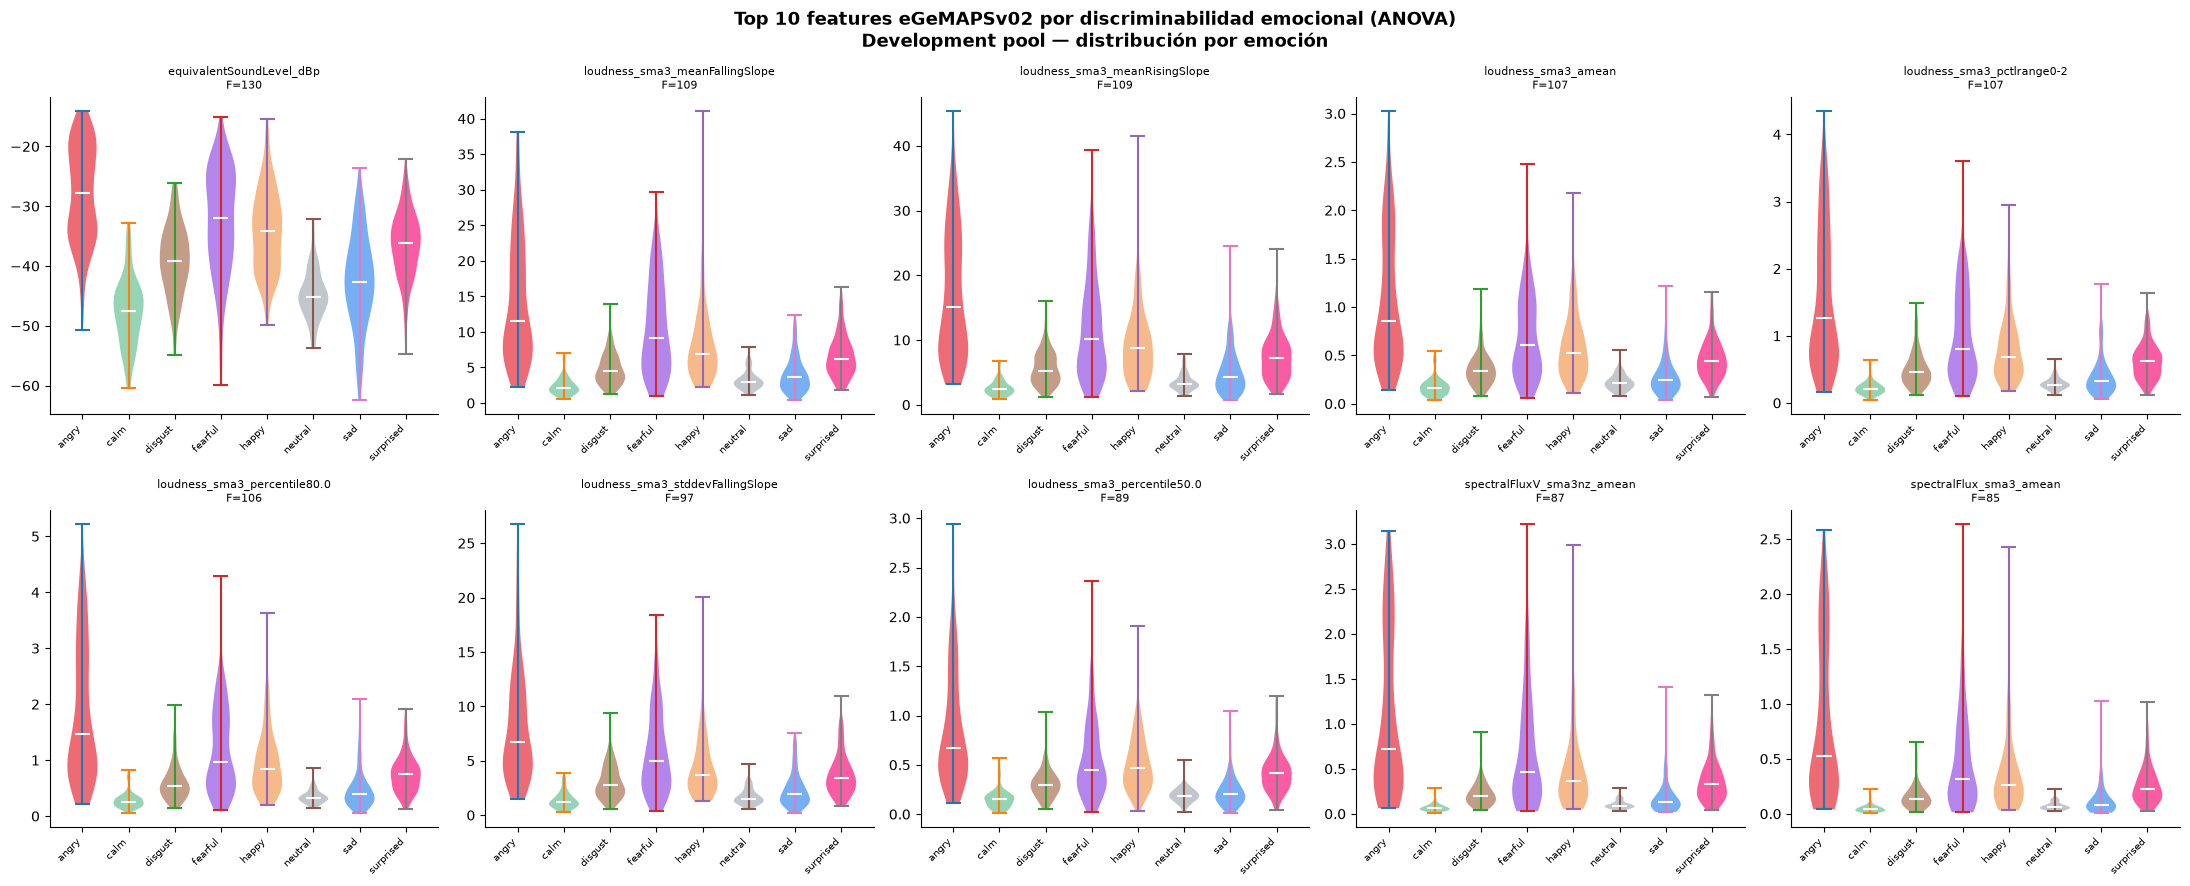

Figura guardada: reports/figures/anova_top10_egemaps.png


In [7]:
# Visualización: Top 10 features — violin plots por emoción
from sklearn.preprocessing import StandardScaler

top10 = anova_df.head(10)["feature"].tolist()
EMOTION_PALETTE = {
    "neutral":"#ADB5BD", "calm":"#74C69D", "happy":"#F4A261", "sad":"#4895EF",
    "angry":"#E63946", "fearful":"#9B5DE5", "disgust":"#B07D62", "surprised":"#F72585",
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(
    "Top 10 features eGeMAPSv02 por discriminabilidad emocional (ANOVA)\n"
    "Development pool — distribución por emoción",
    fontsize=13, fontweight="bold"
)

for ax, feat in zip(axes.flatten(), top10):
    f_val = anova_df.loc[anova_df["feature"] == feat, "F"].values[0]
    for j, emo in enumerate(emotions):
        data = egem_merged.loc[egem_merged["emotion_original"] == emo, feat].values
        parts = ax.violinplot(data, positions=[j], showmedians=True, widths=0.65)
        color = EMOTION_PALETTE.get(emo, "steelblue")
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.75)
        parts["cmedians"].set_color("white")
        parts["cmedians"].set_linewidth(1.5)

    ax.set_title(f"{feat[:32]}\nF={f_val:.0f}", fontsize=8)
    ax.set_xticks(range(len(emotions)))
    ax.set_xticklabels(emotions, rotation=45, ha="right", fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "anova_top10_egemaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: reports/figures/anova_top10_egemaps.png")

### Lectura del ranking ANOVA

El resultado es más específico de lo que la descripción de eGeMAPS en la Sección 1 dejaba anticipar. Las 10 features más discriminativas **no** son de pitch (F0) ni de calidad vocal (jitter, HNR) — son casi todas de **energía/loudness** (8 de 10) más dos de **spectral flux** (velocidad de cambio del espectro). `equivalentSoundLevel_dBp` encabeza el ranking con F=129.8, muy por encima de la mediana (F=20.6 sobre las 88 features), y 74/88 features tienen p < 0.001.

> #### Disclaimer
> ---
> Los valores (p) se utilizan únicamente como descripción exploratoria y no como confirmación inferencial individual de cada feature; no se aplicó una corrección por comparaciones múltiples porque el ranking no interviene directamente en la selección del modelo.

Esto tiene una lectura directa en términos de arousal/valence: la energía y su dinámica temporal, el patrón observado es consistente con diferencias de arousal — se ve en los violin plots, donde esas dos familias de emociones ocupan rangos de loudness claramente distintos. Lo que estas features **no** capturan es la dimensión de **valence** dentro de un mismo nivel de arousal — por ejemplo, `sad` y `calm`/`neutral` comparten bajo arousal pero tienen valence opuesta, y ninguna feature de loudness debería, en principio, distinguirlos bien. Vale la pena tener esto presente: es la primera señal de lo que en notebook 3 se confirma como el cuello de botella central del proyecto (confusión Q3 vs. Q4).

---
## 6 · PCA — Varianza explicada

El PCA sirve para dos propósitos:
1. **Diagnóstico:** ¿cuánta redundancia tienen las representaciones?
2. **Decisión de notebook 3:** ¿conviene reducir dimensionalidad de wav2vec antes de entrenar?

> El scaler y el PCA **se ajustan sobre el development pool completo** a efectos de visualización. En notebook 3, se ajustarán **solo en el train de cada fold** para respetar el contrato anti-leakage.

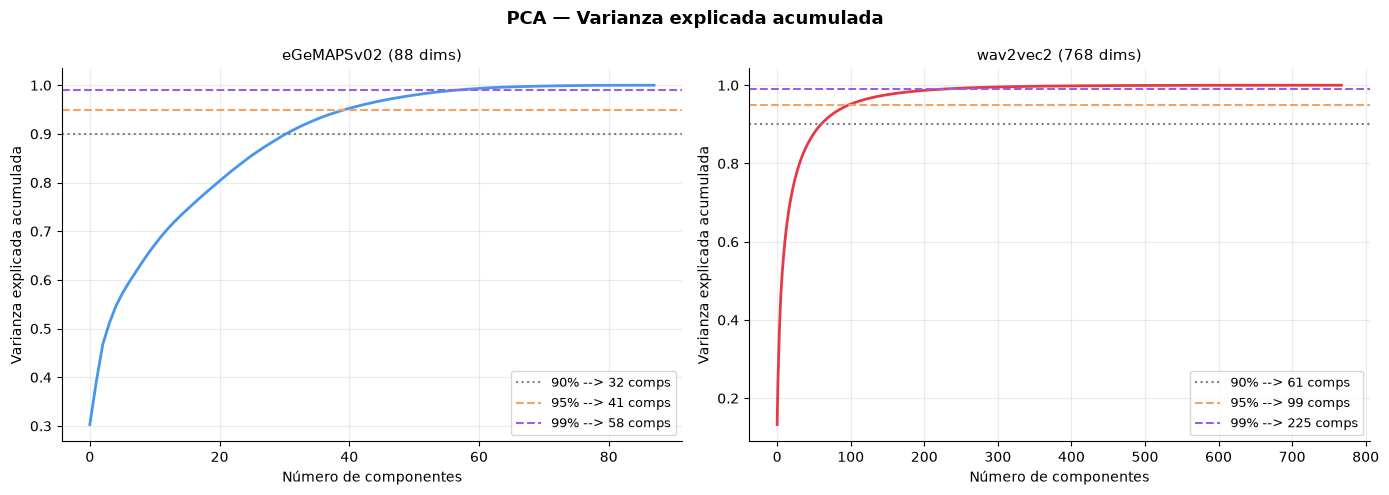

── RESUMEN PCA ──────────────────────────────────────────────
  Representación                   Total    90%    95%    99%
  ──────────────────────────────────────────────────────────
  eGeMAPSv02 (88 dims)                88     32     41     58
  wav2vec2 (768 dims)                768     61     99    225

wav2vec tiene alta redundancia: la mayoría de la varianza se concentra en pocos componentes. PCA es candidato en Sprint 3.
Figura guardada: reports/figures/pca_variance_explained.png


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA — Varianza explicada acumulada", fontsize=13, fontweight="bold")

pca_results = {}

for ax, X, name, color in [
    (axes[0], X_egem,  "eGeMAPSv02 (88 dims)","#4895EF"),
    (axes[1], X_wav2v, "wav2vec2 (768 dims)","#E63946"),
]:
    X_sc = StandardScaler().fit_transform(X)
    pca = PCA(random_state=cfg.seed)
    pca.fit(X_sc)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    n90 = int(np.searchsorted(cumvar, 0.90)) + 1
    n95 = int(np.searchsorted(cumvar, 0.95)) + 1
    n99 = int(np.searchsorted(cumvar, 0.99)) + 1
    pca_results[name] = {"n90": n90, "n95": n95, "n99": n99, "total": X.shape[1]}

    ax.plot(cumvar, color=color, linewidth=2)
    ax.axhline(0.90, color="gray",   linestyle=":",  label=f"90% --> {n90} comps")
    ax.axhline(0.95, color="#F4A261",linestyle="--", label=f"95% --> {n95} comps")
    ax.axhline(0.99, color="#9B5DE5",linestyle="--", label=f"99% --> {n99} comps")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Número de componentes")
    ax.set_ylabel("Varianza explicada acumulada")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_variance_explained.png", dpi=150, bbox_inches="tight")
plt.show()

print("── RESUMEN PCA ──────────────────────────────────────────────")
print(f"  {'Representación':<30}  {'Total':>6}  {'90%':>5}  {'95%':>5}  {'99%':>5}")
print("  " + "─" * 58)
for name, r in pca_results.items():
    print(f"  {name:<30}  {r['total']:>6}  {r['n90']:>5}  {r['n95']:>5}  {r['n99']:>5}")
print()
print("wav2vec tiene alta redundancia: la mayoría de la varianza se concentra en pocos componentes. PCA es candidato en notebook 3.")
print("Figura guardada: reports/figures/pca_variance_explained.png")

### Lectura de PCA — matizando "alta redundancia"

En cantidad absoluta de componentes, wav2vec necesita más que eGeMAPS para los mismos umbrales de varianza (95%: 99 vs. 41 componentes). La afirmación de "alta redundancia" solo es cierta en términos **relativos** a la dimensionalidad original:

| Representación | Dims totales | 90% | 95% | 99% | % de dims para 95% |
|---|---|---|---|---|---|
| eGeMAPSv02 | 88 | 32 | 41 | 58 | 46.6% |
| wav2vec2 | 768 | 61 | 99 | 225 | 12.9% |

wav2vec necesita explicar el 95% de su varianza con solo el 12.9% de sus dimensiones originales, frente al 46.6% que necesita eGeMAPS — en ese sentido relativo sí es más redundante, y PCA (o una capa de proyección aprendida) es un candidato razonable para notebook 3. Pero conviene ser precisos en el informe: eGeMAPS es la representación *más compacta en términos absolutos* para retener la misma varianza.

---
## 7 · t-SNE — Estructura geométrica

Reducción no lineal a 2D para explorar visualmente si la geometría del espacio de features está dominada por:
- **Emoción** (deseable: clusters bien separados)
- **Sexo / Identidad del hablante** (indeseable: dominancia de identidad sobre emoción)

Se comparan ambas representaciones en las mismas condiciones (StandardScaler + t-SNE).

In [9]:
from sklearn.manifold import TSNE

def run_tsne(X: np.ndarray, seed: int, perplexity: int = 30) -> np.ndarray:
    X_sc = StandardScaler().fit_transform(X)
    return TSNE(
        n_components=2, random_state=seed,
        perplexity=perplexity, verbose=0
    ).fit_transform(X_sc)

print("Calculando t-SNE (puede tardar ~1-2 min)...")
emb_egem = run_tsne(X_egem,  cfg.seed)
emb_wav2v = run_tsne(X_wav2v, cfg.seed)
print("t-SNE completado: OK")

Calculando t-SNE (puede tardar ~1-2 min)...
t-SNE completado: OK


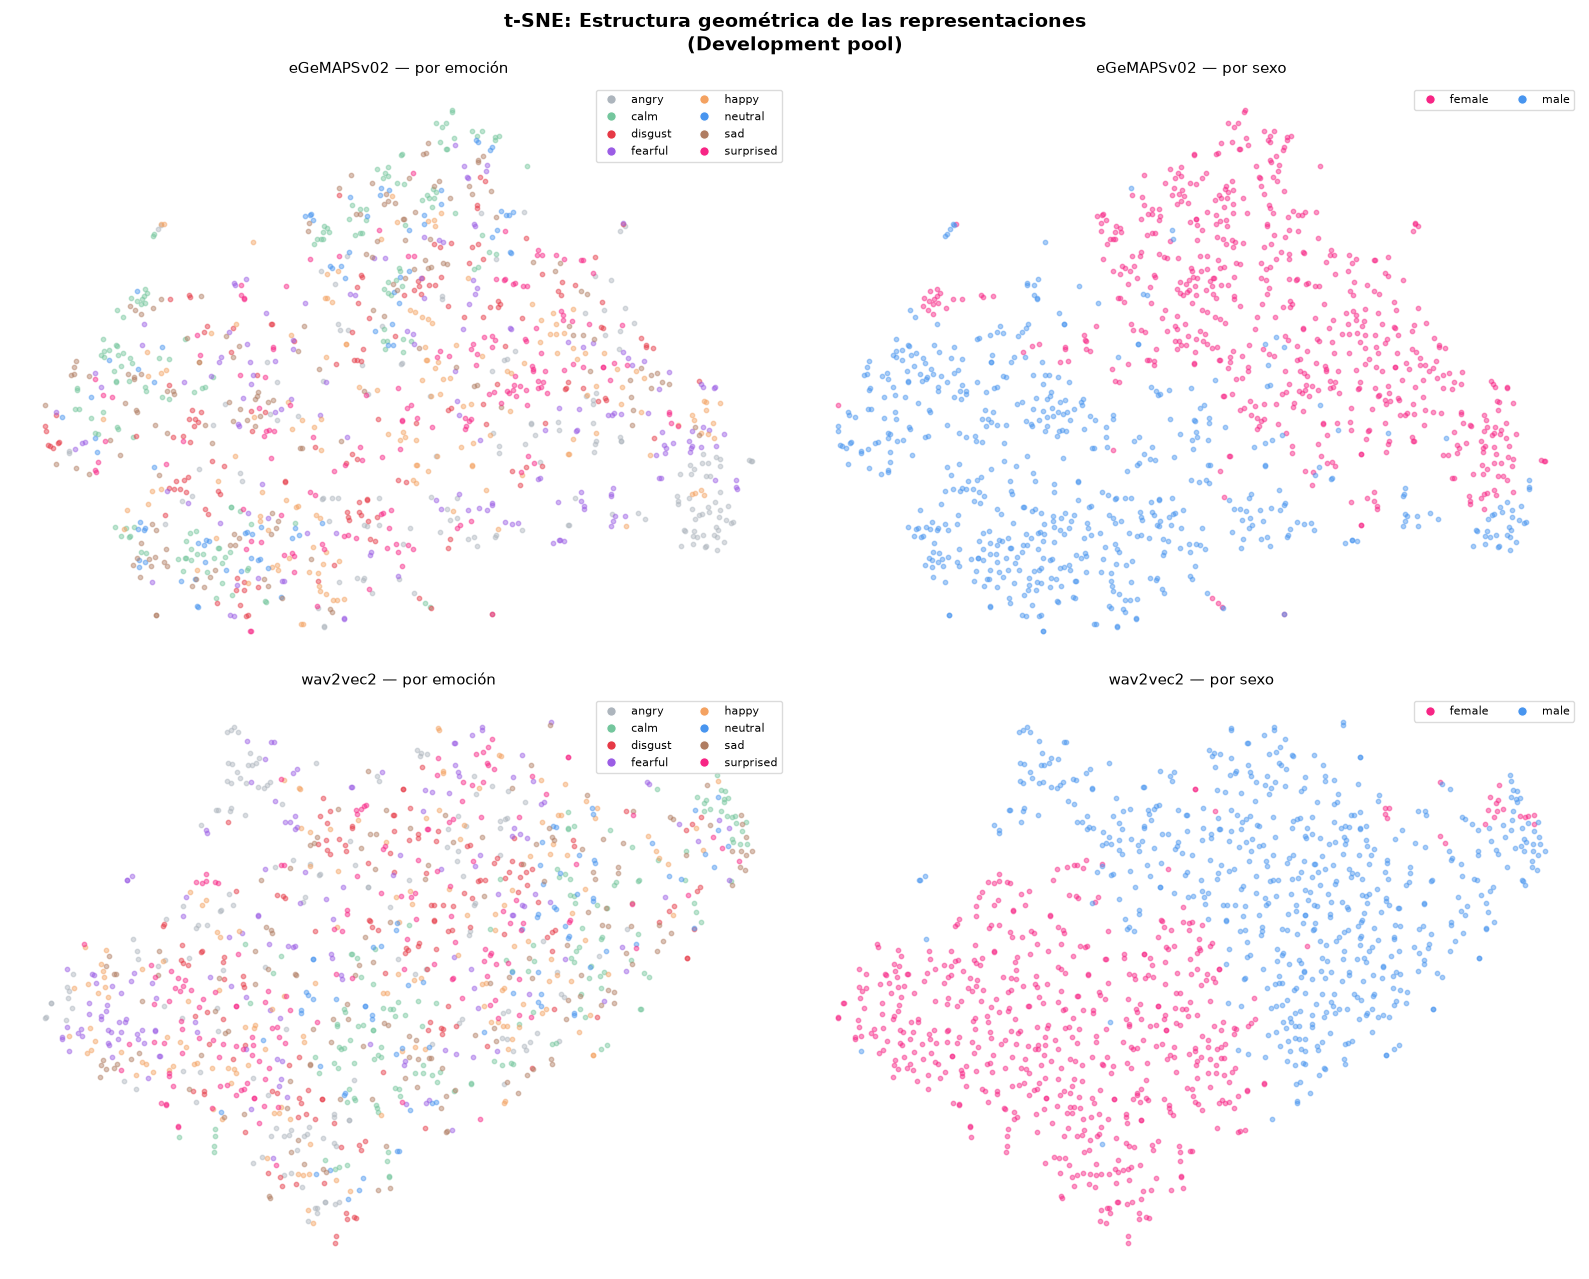

Figura guardada: reports/figures/tsne_repr_comparison.png


In [10]:
from matplotlib.lines import Line2D

EMOTION_PALETTE_LIST = [
    "#ADB5BD","#74C69D","#E63946","#9B5DE5",
    "#F4A261","#4895EF","#B07D62","#F72585",
]
SEX_PALETTE = {"female": "#F72585", "male": "#4895EF"}

emotions_sorted = sorted(np.unique(y_emo))
emo_palette = dict(zip(emotions_sorted, EMOTION_PALETTE_LIST))

def scatter_labeled(ax, emb, labels, palette_dict, title, alpha=0.45, s=10):
    for label, color in palette_dict.items():
        mask = np.array(labels) == label
        ax.scatter(emb[mask, 0], emb[mask, 1], c=color, alpha=alpha, s=s, label=label)
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis("off")
    ax.legend(
        handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=7, label=l)
            for l, c in palette_dict.items()
        ],
        fontsize=8, loc="best", ncol=2, framealpha=0.7
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle(
    "t-SNE: Estructura geométrica de las representaciones\n(Development pool)",
    fontsize=14, fontweight="bold"
)

scatter_labeled(axes[0,0], emb_egem,  y_emo, emo_palette, "eGeMAPSv02 — por emoción")
scatter_labeled(axes[0,1], emb_egem,  y_sex, SEX_PALETTE, "eGeMAPSv02 — por sexo")
scatter_labeled(axes[1,0], emb_wav2v, y_emo, emo_palette, "wav2vec2 — por emoción")
scatter_labeled(axes[1,1], emb_wav2v, y_sex, SEX_PALETTE, "wav2vec2 — por sexo")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tsne_repr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: reports/figures/tsne_repr_comparison.png")

### Lectura de t-SNE — ¿emoción o identidad?

La comparación visual proporciona una evidencia exploratoria sobre la organización local de las representaciones. Debido a que t-SNE es una proyección no lineal que puede distorsionar la geometría global, los patrones observados no se interpretan como una medida cuantitativa de separabilidad ni como prueba de que una variable domine causalmente el espacio latente.

- **eGeMAPSv02 por emoción:** se distinguen agrupamientos parciales, sobre todo entre emociones de alto y bajo arousal (consistente con el hallazgo de la Sección 5); hay superposición dentro de cada grupo de arousal, esperable dado que loudness no captura valence.
- **eGeMAPSv02 por sexo:** separación mucho más nítida en dos regiones — F0 y features relacionadas son intrínsecamente dependientes del aparato vocal, así que este resultado es esperable y no es un problema en sí mismo (mientras el modelo no dependa *solo* de esa señal para predecir emoción).
- **wav2vec2 por emoción:** la estructura es visiblemente más difusa que en eGeMAPS — no hay clusters de emoción claramente delimitados con mean pooling.
- **wav2vec2 por sexo:** la separación por sexo es, si acaso, más marcada que en eGeMAPS, pese a que el encoder nunca vio la etiqueta de sexo durante su pre-entrenamiento.

**Conclusión de la sección:** en ambas representaciones la geometría global está más organizada por identidad del hablante (proxy: sexo) que por emoción, y esto es más marcado en wav2vec2 con mean pooling. Es la primera evidencia visual de un problema que se cuantifica formalmente recién en `03b_diagnostics_interpretability_projection.ipynb` (variabilidad por actor) y que motiva explorar pooling temporal más rico en `03c` en lugar de conformarse con el promedio global de `wav2vec2-base`.

---
## 8 · Heatmap de correlación — eGeMAPSv02

Se visualiza la correlación entre las **Top 20 features más discriminativas** (por ANOVA).
Grupos de alta correlación sugieren redundancia y validan la utilidad de reducción de dimensionalidad.

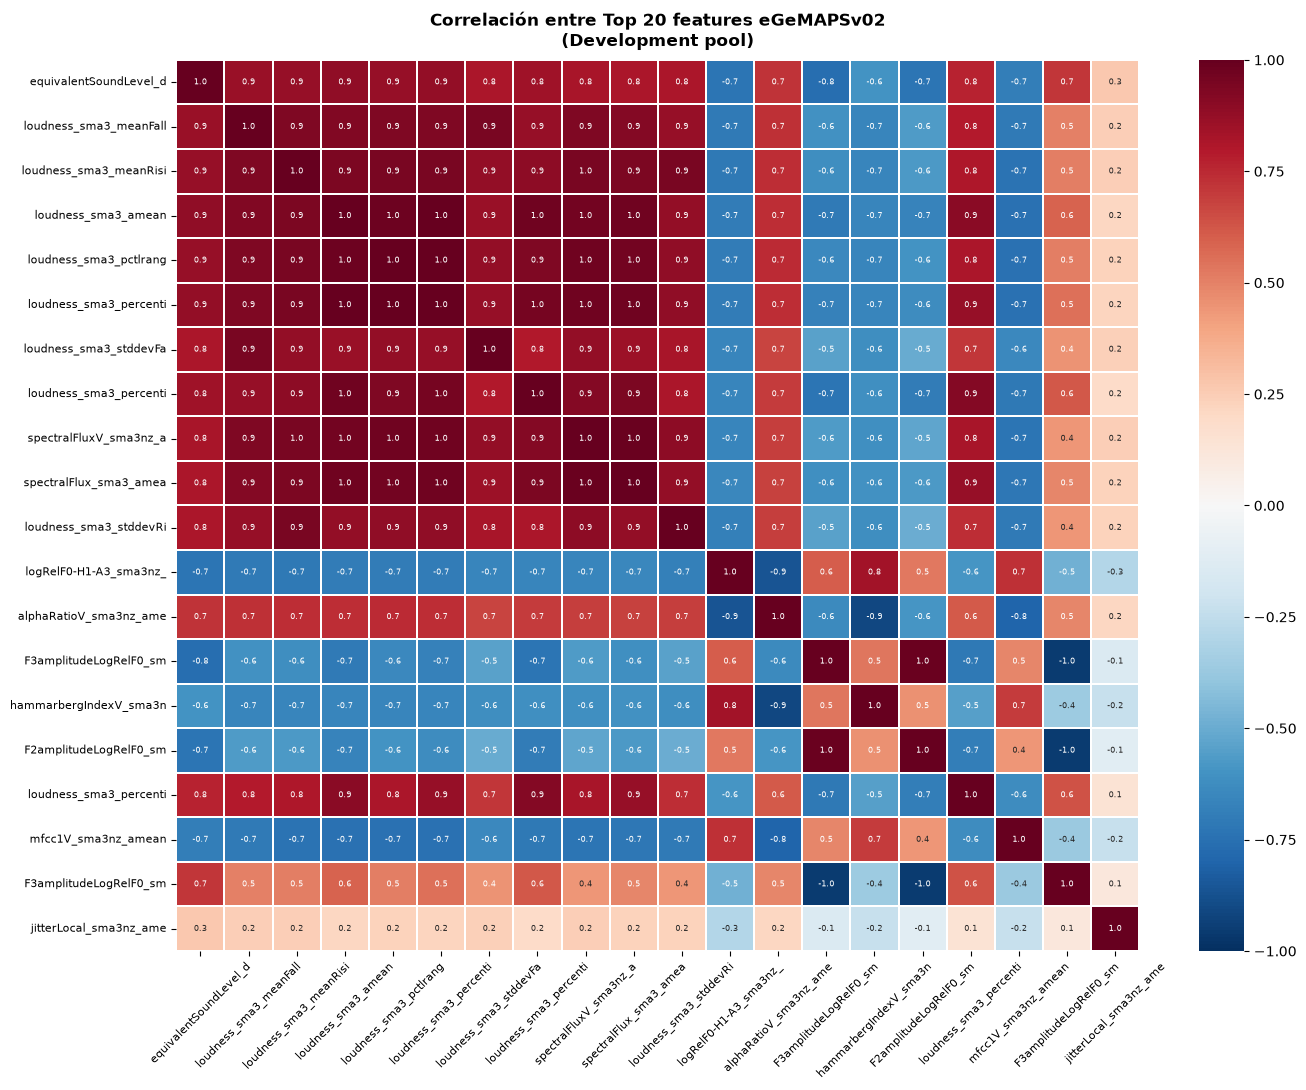

Figura guardada: reports/figures/egemaps_correlation_heatmap.png


In [11]:
top20 = anova_df.head(20)["feature"].tolist()
corr = dev_egem[top20].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr,
    annot=True, fmt=".1f", annot_kws={"size": 6},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="white",
    xticklabels=[f[:22] for f in top20],
    yticklabels=[f[:22] for f in top20],
    ax=ax,
)
ax.set_title(
    "Correlación entre Top 20 features eGeMAPSv02\n(Development pool)",
    fontsize=12, fontweight="bold", pad=10
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "egemaps_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: reports/figures/egemaps_correlation_heatmap.png")

### Lectura del heatmap de correlación

Las 8 features de loudness que dominan el ranking ANOVA (Sección 5) también son, esperablemente, las que forman el bloque de mayor correlación cruzada en este heatmap (r > 0.7 entre varias de ellas) — todas describen la misma dinámica de energía desde ángulos ligeramente distintos (media, percentiles, pendientes de subida/bajada). Esto es una redundancia real dentro del top 20, no solo dentro del total de 88 features, y es un argumento adicional a favor de una selección/regularización de features en notebook 3 (RFECV o Elastic Net) en vez de usar las 88 dimensiones sin criterio.

---
## 9 · Espectrogramas — Ejemplo visual por emoción

Se visualiza el **mel-spectrograma** (log-escala) de un audio de ejemplo por cada emoción, tomado del development pool.

Esto permite chequear visualmente que el preprocesamiento (trimming, sample rate) produce espectrogramas limpios y razonables antes de pasar a notebook 3, y da una intuición cualitativa de cómo se ven las diferencias prosódicas (energía, F0, duración) entre emociones.

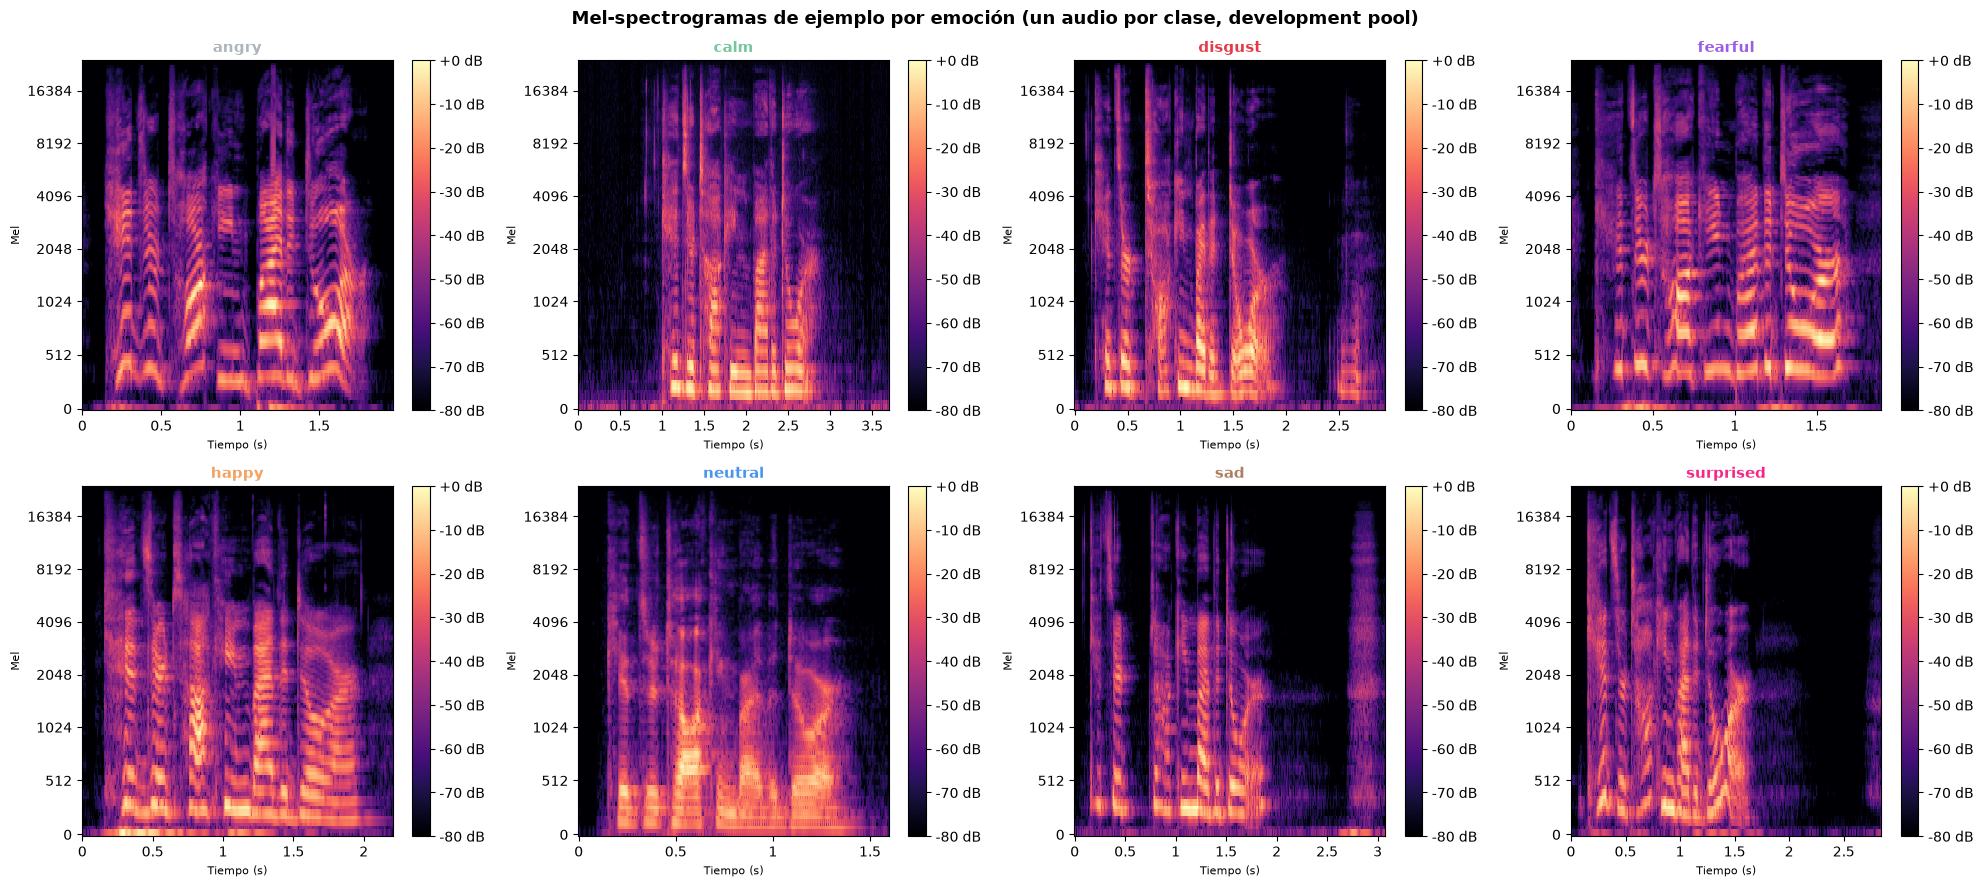

Figura guardada: reports/figures/spectrogram_examples_by_emotion.png


In [12]:
import librosa
import librosa.display

N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

example_rows = {
    emo: dev_meta.loc[dev_meta["emotion_original"] == emo].sample(1, random_state=cfg.seed)
    for emo in emotions_sorted
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(
    "Mel-spectrogramas de ejemplo por emoción (un audio por clase, development pool)",
    fontsize=13, fontweight="bold"
)

for ax, emo in zip(axes.flatten(), emotions_sorted):
    row = example_rows[emo].iloc[0]
    audio_path = resolve_path(row["file_path_trimmed"])
    y, sr = librosa.load(str(audio_path), sr=None, mono=True)

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    S_db = librosa.power_to_db(S, ref=np.max)

    img = librosa.display.specshow(
        S_db, sr=sr, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", ax=ax, cmap="magma",
    )
    ax.set_title(emo, fontsize=11, fontweight="bold", color=emo_palette[emo])
    ax.set_xlabel("Tiempo (s)", fontsize=8)
    ax.set_ylabel("Mel", fontsize=8)
    fig.colorbar(img, ax=ax, format="%+2.0f dB")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "spectrogram_examples_by_emotion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: reports/figures/spectrogram_examples_by_emotion.png")

### Chequeo cualitativo

Los ocho espectrogramas de ejemplo no muestran artefactos de trimming (cortes abruptos, silencios residuales largos) ni ruido de banda ancha atípico — el preprocesamiento de notebook 1 se sostiene también a nivel espectral y no solo en las métricas agregadas de duración/trim_ratio ya auditadas.

---
## Conclusiones del notebook

### Hallazgos del EDA

**ANOVA — eGeMAPSv02:** el ranking de discriminabilidad emocional está dominado por **loudness/energía** (8 de las 10 features top) y **spectral flux** (2 de 10) — no por F0 ni por calidad vocal, que era la expectativa inicial en la Sección 1. F-stat máximo 129.8 (`equivalentSoundLevel_dBp`), mediano 20.6, con 74/88 features significativas a p < 0.001. La lectura funcional es que estas features capturan bien la dimensión de **arousal** (alto vs. bajo) pero no la de **valence** dentro de un mismo nivel de arousal.

**PCA:** eGeMAPS es más compacto en términos absolutos (41 componentes para el 95% de varianza) pero relativamente menos redundante que wav2vec2, que retiene el 95% de su varianza con apenas el 12.9% de sus 768 dimensiones originales (99 componentes) frente al 46.6% que necesita eGeMAPS. Esto motiva evaluar PCA o proyecciones aprendidas sobre wav2vec en notebook 3.

**t-SNE:** en ambas representaciones, la geometría global está más organizada por sexo del hablante que por emoción; el efecto es más marcado en wav2vec2 con mean pooling, que muestra clusters de emoción notablemente más difusos que eGeMAPS. Este es el primer indicio visual — luego cuantificado en `03b` — de que el mean pooling global de wav2vec2 retiene información de identidad del hablante a expensas de estructura emocional, lo que termina motivando la representación temporal explorada en `03c`.

**Correlación (heatmap):** las mismas features de loudness que dominan el ANOVA forman también el bloque más correlacionado del top 20 (r > 0.7 entre varias), confirmando que buena parte de la señal discriminativa de eGeMAPS es redundante dentro de una misma familia acústica — no solo dispersa entre las 88 dimensiones totales.

### Hilo conductor para el informe final

El hallazgo más reutilizable de este notebook es el vínculo **loudness ↔ arousal ↔ límite del EDA no supervisado**: las features más discriminativas de eGeMAPS separan bien alto vs. bajo arousal, pero no valence — y por lo tanto no deberían, en principio, resolver bien la distinción sad (Q3) vs. calm/neutral (Q4), que comparten bajo arousal.